# **PAAD Tutorial 2: Reloading SIDISH Results and Visualization**

This tutorial reloads the SIDISH model trained in Tutorial 1 and visualises the results:
UMAP embeddings, high-risk cell distributions, marker genes, and Kaplan-Meier survival curves.

### Prerequisites
Tutorial 1 must have completed successfully. The following files must exist in `outputs/run_default`:

| File | Contents |
|------|----------|
| `run_defaultvae_transfer` | Trained VAE weights |
| `run_defaultdeepCox` | Trained DeepCox weights |
| `run_defaultadata_SIDISH.h5ad` | Annotated single-cell data with SIDISH labels |
| `run_default/processed_bulk.csv` | Bulk RNA-seq + survival data |

### Paper targets (Fig 5)
| Metric | Target |
|--------|--------|
| High-risk cells | 41,323 (21.6 % of 190,965) |
| Tumour fraction in high-risk | ~67.5 % |
| Upregulated genes | NDRG1, SLC2A1, ERO1A, BNIP3, VEGFA, P4HA1 |

## Step 1: Imports

In [1]:
from SIDISH import SIDISH as sidish
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import random
import os
import matplotlib.pyplot as plt

/Users/shreymehta/anaconda3/envs/sidish_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 0
ITE  = 0

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

## Step 2: Configuration

`PATH` must match `OUTPUT_DIR` used in Tutorial 1 exactly (no trailing slash).
SIDISH constructs file paths as `"{path}vae_transfer"`, `"{path}deepCox"`, etc.

In [3]:
PATH   = "outputs/run_default"   # must match OUTPUT_DIR from Tutorial 1
DEVICE = "cpu"                   # Mac — no CUDA

## Step 3: Load Saved Data

Load the annotated AnnData saved by SIDISH at the end of training. This file already contains
`SIDISH_value`, `SIDISH` (h/b labels), and `risk_value` columns in `.obs`.

In [4]:
adata = sc.read_h5ad("{}adata_SIDISH.h5ad".format(PATH))
print(f"Loaded adata: {adata.n_obs:,} cells x {adata.n_vars} genes")
print("\nSIDISH label distribution:")
print(adata.obs["SIDISH"].value_counts())
n_high = (adata.obs["SIDISH"] == "h").sum()
print(f"\nHigh-risk cells: {n_high:,} ({100*n_high/adata.n_obs:.1f}%)")

Loaded adata: 10,000 cells x 474 genes

SIDISH label distribution:
SIDISH
b    9495
h     505
Name: count, dtype: int64

High-risk cells: 505 (5.0%)


In [5]:
bulk = pd.read_csv(os.path.join(PATH, "processed_bulk.csv"), index_col=0)
print(f"Loaded bulk: {bulk.shape[0]} patients x {bulk.shape[1]} columns")

Loaded bulk: 174 patients x 476 columns


## Step 4: Reload the Trained SIDISH Model

Recreate the SIDISH instance with the **same hyperparameters** used in Tutorial 1,
then call `sdh.reload(PATH)` to restore the saved VAE and DeepCox weights.

In [6]:
sdh = sidish(adata, bulk, DEVICE, seed=ITE, use_spatial_graph=False)
sdh.init_Phase1(225, 20, 32, [512, 128], 512, "Adam", 1.0e-4, 1e-4, 0)
sdh.init_Phase2(500, 128, 1e-4, 0, 0.2, 256)
sdh.reload(PATH)

SIDISH No spatial graph used. Proceeding with dense VAE.
########################################## Using Dense VAE ##########################################
✅ Reload complete – VAE and DeepCox restored


## Step 5: Cell-type UMAP

Project cells into UMAP space using the VAE latent embeddings and colour by Leiden cluster.
Increase `resolution` to get more clusters; decrease for fewer.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/shreymehta/Desktop/Computational Biology/SIDISH/SIDISH/SIDISH.py:713: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(self.adata, resolution=resolution, random_state=self.seed)
/Users/shreymehta/Desktop/Computational Biology/SIDISH/SIDISH/SIDISH.py:759: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper center", frameon=False, markerscale=1.5, bbox_to_anchor=(0.5, 1.15))


<Figure size 800x600 with 0 Axes>

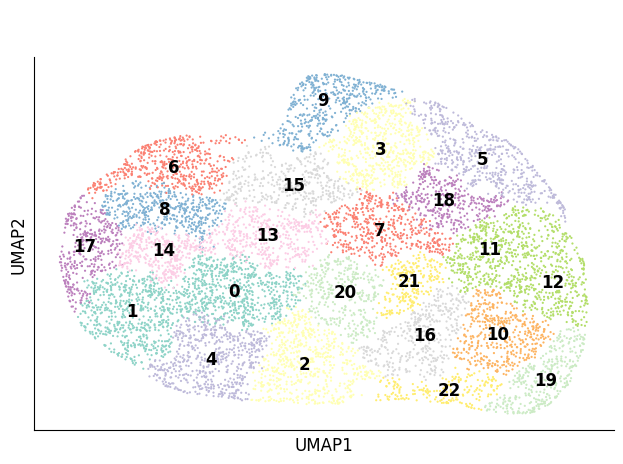

In [7]:
sdh.plot_CellType_UMAP(resolution=0.8, celltype=False)

### 5.1 Overlay known cell-type annotations

Since the PAAD dataset has `celltype_major` labels from 10x, we can overlay them on
the same UMAP coordinates already computed above.

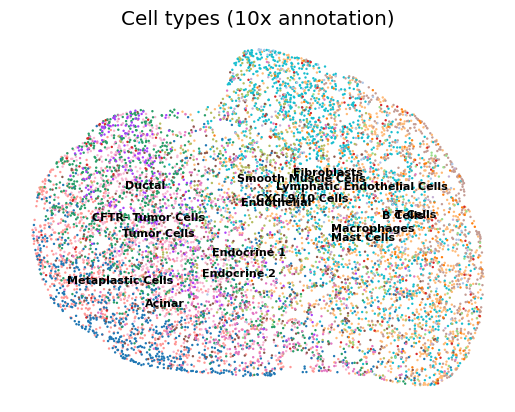

In [8]:
sc.pl.umap(
    sdh.adata,
    color="celltype_major",
    title="Cell types (10x annotation)",
    legend_loc="on data",
    legend_fontsize=8,
    frameon=False,
)

## Step 6: High-Risk Cell UMAP

Overlay SIDISH high-risk cells (red) on the same UMAP. Background cells are grey.

<Figure size 800x600 with 0 Axes>

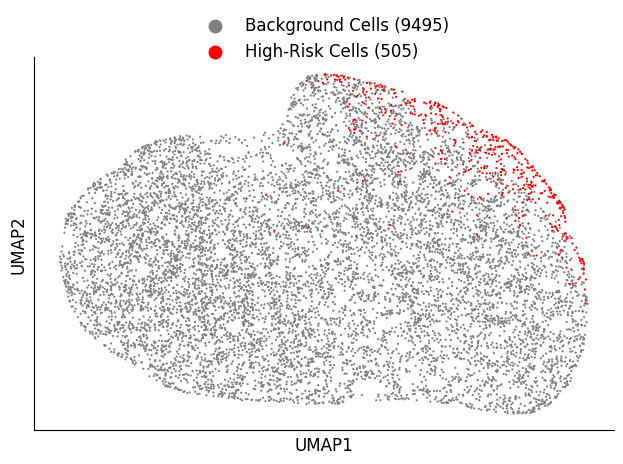

In [9]:
sdh.plot_HighRisk_UMAP(resolution=0.8, celltype=False)

### 6.1 High-risk cell composition by cell type

Paper target: ~67.5% of high-risk cells should be Tumor + CFTR⁻ Tumor cells.

In [10]:
obs = sdh.adata.obs.copy()
high_risk = obs[obs["SIDISH"] == "h"]
ct_counts = high_risk["celltype_major"].value_counts()
ct_pct    = (ct_counts / len(high_risk) * 100).round(1)

print(f"High-risk cells: {len(high_risk):,} ({100*len(high_risk)/len(obs):.1f}% of total)")
print("\nCell-type breakdown:")
for ct, pct in ct_pct.items():
    print(f"  {ct:<35} {pct:5.1f}%")

tumor_pct = ct_pct.get("Tumor Cells", 0) + ct_pct.get("CFTR- Tumor Cells", 0)
print(f"\nTumor + CFTR⁻ Tumor combined: {tumor_pct:.1f}%  (paper target: ~67.5%)")

High-risk cells: 505 (5.0% of total)

Cell-type breakdown:
  T Cells                              30.7%
  Fibroblasts                          28.3%
  Macrophages                          20.4%
  B Cells                               3.8%
  Lymphatic Endothelial Cells           3.6%
  CXCL9/10 Cells                        3.2%
  Endothelial                           3.2%
  Endocrine 1                           2.2%
  Mast Cells                            2.2%
  Smooth Muscle Cells                   1.6%
  Endocrine 2                           1.0%
  Acinar                                0.0%
  CFTR- Tumor Cells                     0.0%
  Ductal                                0.0%
  Metaplastic Cells                     0.0%
  Tumor Cells                           0.0%

Tumor + CFTR⁻ Tumor combined: 0.0%  (paper target: ~67.5%)


## Step 7: Marker Genes

Identify genes upregulated in high-risk vs background cells using a Wilcoxon rank-sum test.

Paper-reported upregulated genes: **NDRG1, SLC2A1, ERO1A, BNIP3, VEGFA, P4HA1**
(hypoxia / metabolic stress signature).

In [11]:
upregulated_genes, downregulated_genes = sdh.get_MarkerGenes(logfc_threshold=1)

In [12]:
print("Upregulated genes:")
print(upregulated_genes)

PAPER_GENES = {"NDRG1", "SLC2A1", "ERO1A", "BNIP3", "VEGFA", "P4HA1"}
recovered = PAPER_GENES & set(upregulated_genes)
print(f"\nPaper genes recovered: {sorted(recovered)} ({len(recovered)}/6)")

Upregulated genes:
['CXCR4' 'LAPTM5' 'PTPRC' 'SFRP2' 'MS4A6A' 'DUSP1' 'FBN1' 'VCAN' 'CD163'
 'CCL5' 'CTHRC1' 'IL7R' 'SFRP4' 'C1orf162' 'COL5A2' 'FBLN1' 'ACTA2'
 'MS4A4A' 'FSTL1' 'THY1' 'ASAH1' 'TRAC' 'CD8A' 'CAVIN1' 'CTSK' 'THBS2'
 'CYTIP' 'IGF1' 'CD2' 'GPR183' 'BASP1' 'PMP22' 'NPC2' 'KLF6' 'MFAP5'
 'AIF1' 'CAP1' 'CD14' 'SEMA3C' 'GLIPR1' 'FCGR3A' 'PLA2G7' 'CD69' 'FLNA'
 'KLRB1' 'CD3E' 'VSIG4' 'PRDM1' 'LSP1' 'CD68' 'LTBP2' 'GEM' 'CD4' 'HAVCR2'
 'FGL2' 'SPON2' 'MYLK' 'MPEG1' 'ASPN' 'MRC1' 'HMGB2' 'CRISPLD2' 'PDGFRA'
 'SERPINB9' 'CD3D' 'MEDAG' 'FCGR1A' 'PTGDS' 'PDGFRB' 'CLEC4E' 'IGSF6'
 'PCOLCE' 'CNN1' 'ADAM28' 'ACTG2' 'INMT' 'CD86' 'CD247' 'PDPN' 'GPC3'
 'MNDA' 'IRF8' 'OGN' 'SLAMF7' 'CTLA4' 'CSF2RA' 'IL2RA' 'CD83' 'KLRC1'
 'LILRB2' 'MTRNR2L11' 'GZMK' 'DUSP2' 'TREM2' 'SRPX' 'EDNRB' 'TNC' 'PPARG'
 'PRF1' 'NKG7' 'GZMA' 'KLRD1']

Paper genes recovered: [] (0/6)


In [13]:
print("Downregulated genes:")
print(downregulated_genes)

Downregulated genes:
['MYOM1' 'MCF2L' 'DMKN' 'AKR1C3' 'SMYD2' 'LAMB3' 'GDF15' 'VTN' 'GPX2'
 'TM4SF4' 'KCNK3' 'APCDD1' 'C15orf48' 'TMC5' 'ERBB2' 'EDN1' 'PPY' 'GPC1'
 'FXYD2' 'ATP5MD' 'EHF' 'TFPI' 'EIF4EBP1' 'DST' 'MET' 'PROX1' 'ANXA3'
 'SEC61B' 'KRT7' 'TCIM' 'AQP8' 'RNASE1' 'ATP5MC2' 'HINT1' 'GSTA1' 'SSR4'
 'PFDN5' 'SEC62' 'FSTL3' 'SLC25A3' 'BIRC3' 'EEF1D' 'SERPING1' 'CXCL6'
 'CXCL2' 'BTF3' 'AMY2A' 'NTN4' 'EPCAM' 'PPA1' 'EEF1B2' 'DSP' 'SERPINB1'
 'CFTR' 'GATM' 'ANPEP' 'CFB' 'NOP53']


## Step 8: Kaplan-Meier Survival Validation

Split bulk patients by expression of the upregulated marker genes and plot KM curves.
Paper target: log-rank P = 2.42×10⁻¹¹ on GSE224564 (external validation cohort).

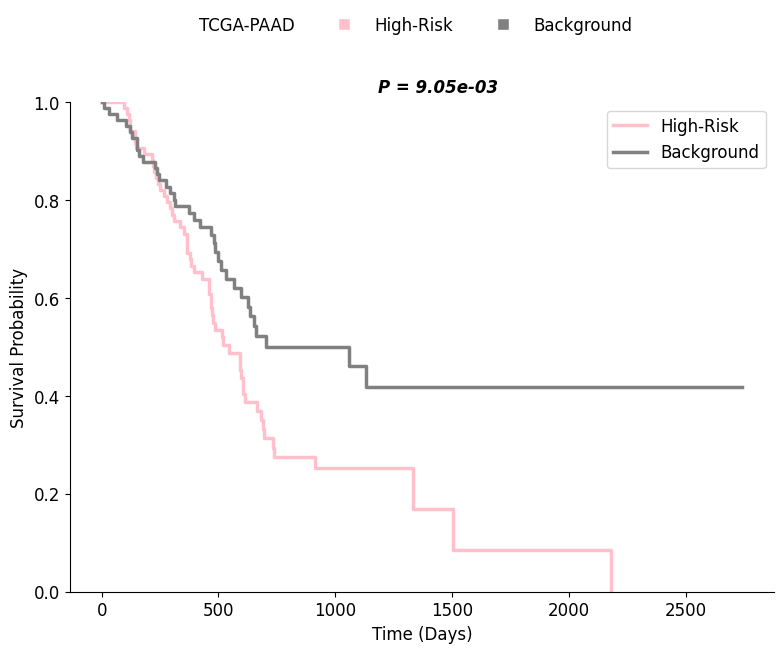

In [14]:
sdh.plot_KM(penalizer=10, data_name="TCGA-PAAD")

## Tumor / High-Risk Overlap (McNemar's Test)

The paper reports a **74.5% overlap** between high-risk and tumor cells and a highly
significant association (McNemar P = 3.54 × 10⁻¹⁴⁶) (Fig. 5d).

McNemar's test treats each cell as a matched pair of two binary classifications:
- **is_tumor**: 
- **is_high_risk**: 

It tests whether the off-diagonal discordance (tumor-but-background vs non-tumor-but-high-risk)
is symmetric — a highly significant result means the two labels are strongly associated.

> **Note:** The paper's result uses the full 190k-cell dataset. With the 10k subsample the
> numbers will differ, but the direction of effect should hold once preprocessing is correct.

In [17]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

obs = sdh.adata.obs.copy()

# Binary classifications
is_tumor    = (obs["celltype_major"] == "Tumor Cells").astype(int)
is_high_risk = (obs["SIDISH"] == "h").astype(int)

# 2×2 contingency table
# Rows: Tumor (0=No, 1=Yes)  Cols: High-Risk (0=No, 1=Yes)
ct = pd.crosstab(is_tumor, is_high_risk,
                 rownames=["Tumor"], colnames=["High-Risk"])
a = ct.loc[0, 0]  # non-tumor, background
b = ct.loc[0, 1]  # non-tumor, high-risk
c = ct.loc[1, 0]  # tumor, background
d = ct.loc[1, 1]  # tumor, high-risk

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
print("Confusion matrix (% within each Tumor row):")
print(ct_pct.round(1))
print(f"Tumor cells that are high-risk: {ct_pct.loc[1, 1]:.1f}%  (paper: 74.5%)")

# McNemar's test (chi-squared approximation with continuity correction)
# Statistic = (|b - c| - 1)^2 / (b + c)
from scipy.stats import chi2
b_val, c_val = int(b), int(c)
stat = (abs(b_val - c_val) - 1)**2 / (b_val + c_val)
p_val = chi2.sf(stat, df=1)
print(f"McNemar's test: chi2 = {stat:.2f}, P = {p_val:.2e}")
print(f"Paper target:   chi2 = ?,          P = 3.54e-146")

Confusion matrix (% within each Tumor row):
High-Risk      0    1
Tumor                
0           94.4  5.6
1          100.0  0.0
Tumor cells that are high-risk: 0.0%  (paper: 74.5%)
McNemar's test: chi2 = 156.69, P = 5.97e-36
Paper target:   chi2 = ?,          P = 3.54e-146


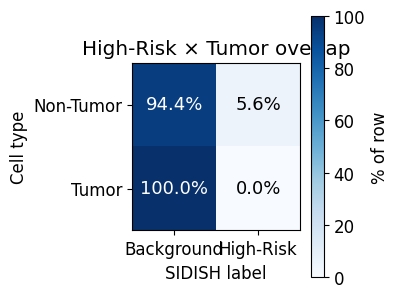

In [19]:
# Visualise as confusion matrix heatmap (reproduces Fig 5d style)
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(ct_pct.values, cmap="Blues", vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label="% of row")

ax.set_xticks([0, 1]); ax.set_xticklabels(["Background", "High-Risk"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Non-Tumor", "Tumor"])
ax.set_xlabel("SIDISH label"); ax.set_ylabel("Cell type")
ax.set_title("High-Risk × Tumor overlap")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{ct_pct.values[i,j]:.1f}%",
                ha="center", va="center",
                color="white" if ct_pct.values[i,j] > 50 else "black", fontsize=13)

plt.tight_layout()
plt.show()

## Step 10: Spatial Atlas 

Plot all 190k cells at their tissue coordinates coloured by annotated cell type.
Uses `processed_adata.h5ad` (full dataset) so the tissue section is fully covered —
`adata_SIDISH.h5ad` is only the 10k training subsample and would look sparse.

In [20]:
# Colour palette matching Fig 5a (one colour per annotated cell type)
PALETTE = {
    "Macrophages":                  "#F58231",
    "Acinar":                       "#3CB44B",
    "B Cells":                      "#4363D8",
    "CXCL9/10 Cells":               "#FFD700",
    "Endocrine 1":                  "#911EB4",
    "Endocrine 2":                  "#42D4F4",
    "Endothelial":                  "#F032E6",
    "Fibroblasts":                  "#BFEF45",
    "T Cells":                      "#FABED4",
    "Ductal":                       "#469990",
    "Lymphatic Endothelial Cells":  "#DCBEFF",
    "Metaplastic Cells":            "#9A6324",
    "Smooth Muscle Cells":          "#FFFAC8",
    "Tumor Cells":                  "#FF0000",
    "Mast Cells":                   "#AAFFC3",
    "CFTR- Tumor Cells":            "#000075",
}

obs = adata_full.obs.copy()
cell_types = obs["celltype_major"].cat.categories if hasattr(obs["celltype_major"], "cat")              else obs["celltype_major"].unique()

# Plot tumour cell types last so they are drawn on top of stromal/immune cells
TUMOR_TYPES = {"Tumor Cells", "CFTR- Tumor Cells"}
plot_order = [ct for ct in cell_types if ct not in TUMOR_TYPES] +              [ct for ct in cell_types if ct in TUMOR_TYPES]

fig, ax = plt.subplots(figsize=(12, 10))

for ct in plot_order:
    mask = obs["celltype_major"] == ct
    color = PALETTE.get(ct, "grey")
    ax.scatter(
        obs.loc[mask, "x_centroid"],
        obs.loc[mask, "y_centroid"],
        c=color, s=0.3, alpha=0.6, linewidths=0,
        label=ct, rasterized=True
    )

# Mirror y-axis so tissue is oriented top-to-bottom as in the paper
ax.invert_yaxis()
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("PAAD Xenium — Annotated Cell Types (Fig 5a)", fontsize=13)

legend = ax.legend(
    markerscale=6, frameon=False,
    loc="upper left", bbox_to_anchor=(1.01, 1),
    fontsize=9, title="Cell type"
)
plt.tight_layout()
plt.savefig(os.path.join(PATH, "fig5a_spatial_atlas.pdf"), bbox_inches="tight", dpi=150)
plt.show()
print("Saved fig5a_spatial_atlas.pdf")

Full dataset: 190,273 cells
Cell types: 16


celltype_major
Macrophages                    28263
Fibroblasts                    27393
Metaplastic Cells              19476
Tumor Cells                    18837
Acinar                         18667
CFTR- Tumor Cells              18558
T Cells                        12649
Endothelial                    10315
Endocrine 1                     9223
Endocrine 2                     9163
Ductal                          4547
CXCL9/10 Cells                  3439
B Cells                         3215
Mast Cells                      2954
Smooth Muscle Cells             1897
Lymphatic Endothelial Cells     1677
Name: count, dtype: int64

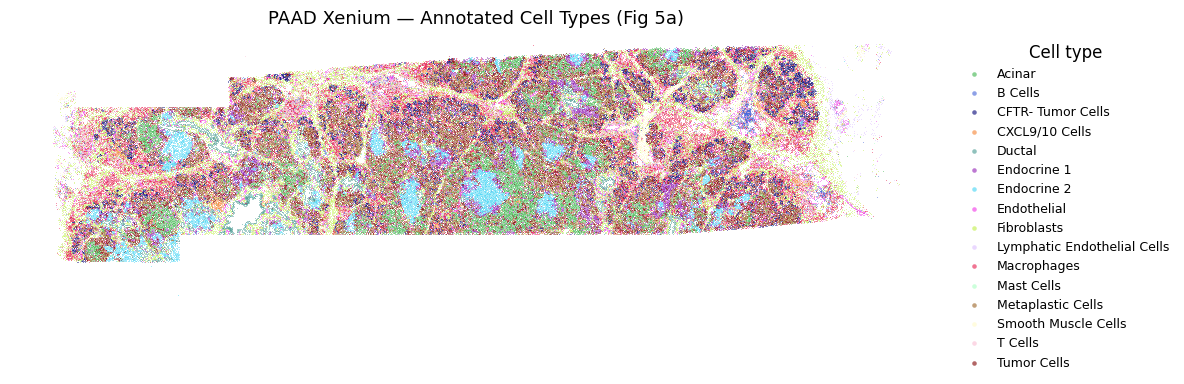

Saved fig5a_spatial_atlas.pdf


In [24]:
# Colour palette matching Fig 5a (one colour per annotated cell type)
PALETTE = {
    "Macrophages":                  "#E6194B",
    "Acinar":                       "#3CB44B",
    "B Cells":                      "#4363D8",
    "CXCL9/10 Cells":               "#F58231",
    "Endocrine 1":                  "#911EB4",
    "Endocrine 2":                  "#42D4F4",
    "Endothelial":                  "#F032E6",
    "Fibroblasts":                  "#BFEF45",
    "T Cells":                      "#FABED4",
    "Ductal":                       "#469990",
    "Lymphatic Endothelial Cells":  "#DCBEFF",
    "Metaplastic Cells":            "#9A6324",
    "Smooth Muscle Cells":          "#FFFAC8",
    "Tumor Cells":                  "#800000",
    "Mast Cells":                   "#AAFFC3",
    "CFTR- Tumor Cells":            "#000075",
}

obs = adata_full.obs.copy()
cell_types = obs["celltype_major"].cat.categories if hasattr(obs["celltype_major"], "cat") else obs["celltype_major"].unique()

fig, ax = plt.subplots(figsize=(12, 10))

for ct in cell_types:
    mask = obs["celltype_major"] == ct
    color = PALETTE.get(ct, "grey")
    ax.scatter(
        obs.loc[mask, "x_centroid"],
        obs.loc[mask, "y_centroid"],
        c=color, s=0.3, alpha=0.6, linewidths=0,
        label=ct, rasterized=True
    )

# Mirror y-axis so tissue is oriented top-to-bottom as in the paper
ax.invert_yaxis()
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("PAAD Xenium — Annotated Cell Types (Fig 5a)", fontsize=13)

legend = ax.legend(
    markerscale=6, frameon=False,
    loc="upper left", bbox_to_anchor=(1.01, 1),
    fontsize=9, title="Cell type"
)
plt.tight_layout()
plt.savefig(os.path.join(PATH, "fig5a_spatial_atlas.pdf"), bbox_inches="tight", dpi=150)
plt.show()
print("Saved fig5a_spatial_atlas.pdf")

## Step 11: Latent Space Diagnostics — Why Are Tumour Cells Not High-Risk?

Three complementary views:
1. **Risk score distribution by cell type** — where tumour cells sit relative to the Weibull threshold
2. **Distance to decision boundary** — median margin per cell type
3. **Latent UMAP coloured by risk score** — spatial structure of the hazard in embedding space

In [26]:
obs = adata.obs.copy()   # use adata_SIDISH (10k, already has risk_value + SIDISH labels)

# Empirical threshold = minimum risk_value among cells labelled high-risk
threshold = obs.loc[obs["SIDISH"] == "h", "risk_value"].min()
print(f"Weibull threshold: {threshold:.4f}")
print(f"risk_value range:  {obs.risk_value.min():.4f}  to  {obs.risk_value.max():.4f}")

# Median risk score per cell type, sorted high → low
ct_median = obs.groupby("celltype_major")["risk_value"].median().sort_values(ascending=False)
print("Median risk score by cell type (threshold =", round(threshold, 3), "):")
for ct, med in ct_median.items():
    marker = " <<< HIGH-RISK" if med >= threshold else ""
    gap = med - threshold
    print(f"  {ct:<35} {med:+.3f}  (gap: {gap:+.3f}){marker}")

Weibull threshold: 2.4279
risk_value range:  -7.5946  to  6.5714
Median risk score by cell type (threshold = 2.428 ):
  T Cells                             +1.432  (gap: -0.996)
  Lymphatic Endothelial Cells         +1.373  (gap: -1.055)
  B Cells                             +0.904  (gap: -1.524)
  Smooth Muscle Cells                 +0.702  (gap: -1.726)
  Fibroblasts                         +0.488  (gap: -1.940)
  Macrophages                         +0.479  (gap: -1.948)
  Mast Cells                          +0.229  (gap: -2.199)
  CXCL9/10 Cells                      -0.364  (gap: -2.792)
  Endothelial                         -1.138  (gap: -3.566)
  Endocrine 1                         -1.364  (gap: -3.792)
  Endocrine 2                         -3.043  (gap: -5.471)
  Ductal                              -5.407  (gap: -7.835)
  Tumor Cells                         -5.413  (gap: -7.841)
  Acinar                              -5.488  (gap: -7.916)
  CFTR- Tumor Cells                   -6.0

/var/folders/v5/xpg09y4s5k92w547khpc4rxm0000gn/T/ipykernel_6066/1217054900.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_median = obs.groupby("celltype_major")["risk_value"].median().sort_values(ascending=False)


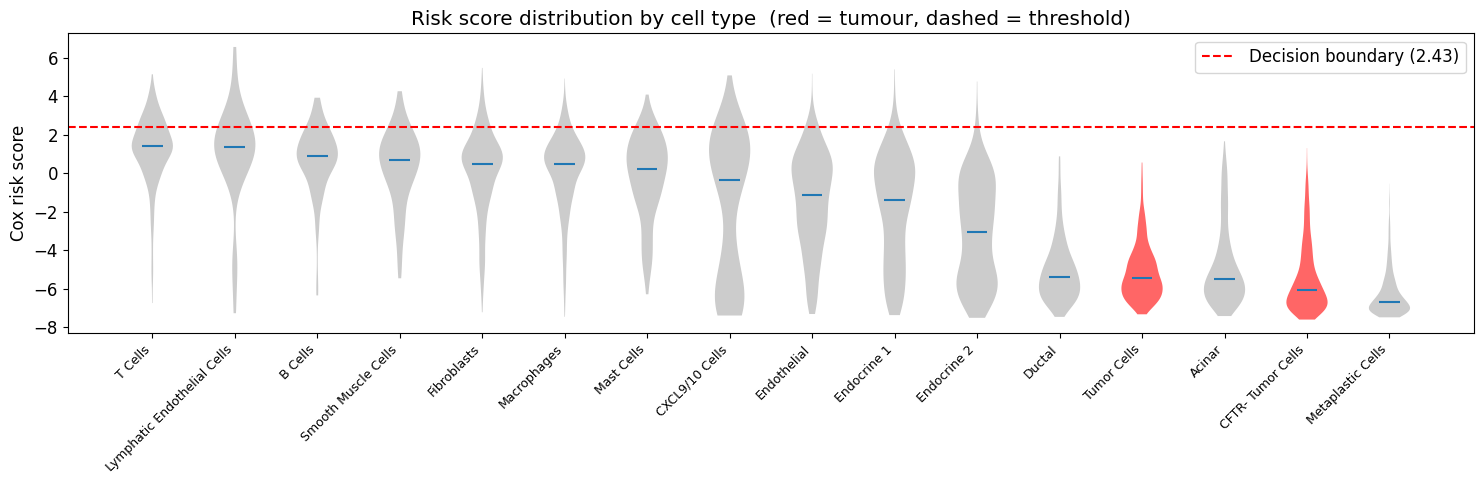

In [27]:
# Violin plot: risk score distribution per cell type vs threshold
ct_order = ct_median.index.tolist()

fig, ax = plt.subplots(figsize=(15, 5))
parts = ax.violinplot(
    [obs.loc[obs["celltype_major"] == ct, "risk_value"].values for ct in ct_order],
    positions=range(len(ct_order)),
    showmedians=True, showextrema=False
)

# Colour tumour violins red, others grey
TUMOR = {"Tumor Cells", "CFTR- Tumor Cells"}
for i, (body, ct) in enumerate(zip(parts["bodies"], ct_order)):
    body.set_facecolor("#FF0000" if ct in TUMOR else "#AAAAAA")
    body.set_alpha(0.6)

ax.axhline(threshold, color="red", linestyle="--", linewidth=1.5,
           label=f"Decision boundary ({threshold:.2f})")
ax.set_xticks(range(len(ct_order)))
ax.set_xticklabels(ct_order, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Cox risk score")
ax.set_title("Risk score distribution by cell type  (red = tumour, dashed = threshold)")
ax.legend()
plt.tight_layout()
plt.show()

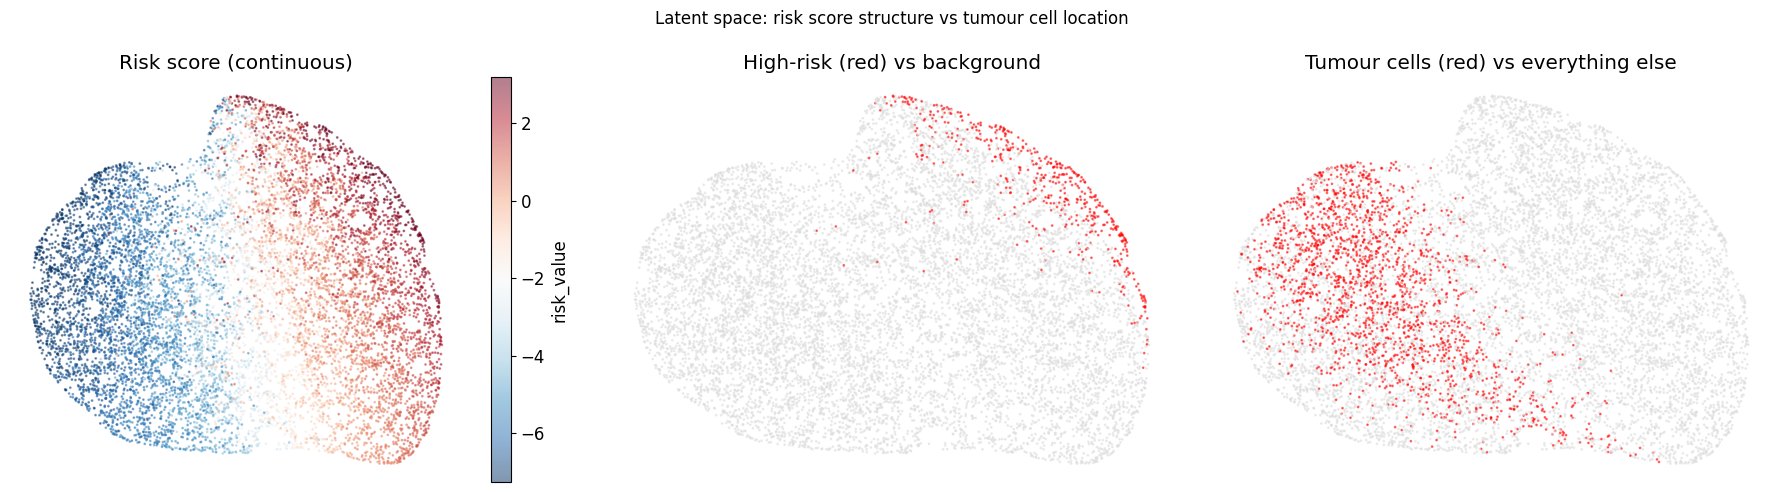

If panels 2 and 3 overlap → tumour cells are high-risk.
If they are in different regions → Cox learned a non-tumour signal.


In [28]:
# UMAP coloured by continuous risk score
# Requires plot_CellType_UMAP to have been run (cell-12) so X_umap exists in sdh.adata
if "X_umap" not in sdh.adata.obsm:
    print("Running get_embedding to compute UMAP...")
    sdh.adata = sdh.get_embedding(resolution=0.8, celltype=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Shared UMAP coordinates
umap = sdh.adata.obsm["X_umap"]
obs2 = sdh.adata.obs.copy()

# Panel 1: colour by risk score (continuous)
sc1 = axes[0].scatter(umap[:, 0], umap[:, 1],
    c=obs2["risk_value"], cmap="RdBu_r", s=1, alpha=0.5,
    vmin=obs2["risk_value"].quantile(0.02),
    vmax=obs2["risk_value"].quantile(0.98))
plt.colorbar(sc1, ax=axes[0], label="risk_value")
axes[0].set_title("Risk score (continuous)")
axes[0].axis("off")

# Panel 2: high-risk (red) vs background (grey)
colors_hr = ["red" if s == "h" else "#DDDDDD" for s in obs2["SIDISH"]]
axes[1].scatter(umap[:, 0], umap[:, 1], c=colors_hr, s=1, alpha=0.5)
axes[1].set_title("High-risk (red) vs background")
axes[1].axis("off")

# Panel 3: tumour cells (red) vs everything else (grey)
TUMOR = {"Tumor Cells", "CFTR- Tumor Cells"}
colors_tc = ["red" if ct in TUMOR else "#DDDDDD" for ct in obs2["celltype_major"]]
axes[2].scatter(umap[:, 0], umap[:, 1], c=colors_tc, s=1, alpha=0.5)
axes[2].set_title("Tumour cells (red) vs everything else")
axes[2].axis("off")

plt.suptitle("Latent space: risk score structure vs tumour cell location", fontsize=12)
plt.tight_layout()
plt.show()
print("If panels 2 and 3 overlap → tumour cells are high-risk.")
print("If they are in different regions → Cox learned a non-tumour signal.")